Task A: DATASET PREPARATION

In [2]:
print("KRITHIKA K - 24BAD061")

KRITHIKA K - 24BAD061


In [3]:
!pip install -q -U kagglehub

In [4]:
import kagglehub
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [5]:
dataset_path = kagglehub.dataset_download(
    "puneet6060/intel-image-classification"
)

print("Datset downloaded to : ")
print(dataset_path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Datset downloaded to : 
/kaggle/input/intel-image-classification


In [6]:
print(os.listdir(dataset_path))

['seg_train', 'seg_pred', 'seg_test']


In [7]:
train_dir=os.path.join(dataset_path,'seg_train','seg_train')
test_dir=os.path.join(dataset_path,'seg_test','seg_test')

print("Training Folder: ", train_dir)
print("Testing Folder: ",test_dir)

Training Folder:  /kaggle/input/intel-image-classification/seg_train/seg_train
Testing Folder:  /kaggle/input/intel-image-classification/seg_test/seg_test


In [8]:
print("Classes: ")
print(os.listdir(train_dir))

Classes: 
['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [9]:
import tensorflow as tf
IMG_SIZE=(224,224)
BATCH_SIZE=32
SEED=42
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds=tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds=tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_name=train_ds.class_names
print("Class Names: ")
print(class_name)
print("\nNumber of classes: ", len(class_name))



Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Class Names: 
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Number of classes:  6


Task B: IMPLEMENTING TRANSFER LEARNING

In [10]:
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [11]:
base_model=ResNet50(weights='imagenet',include_top=False,input_shape=(224,224,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [12]:
base_model.trainable=False

print("Features Extraction Layers Frozen")
print("Base Model trainable: ",base_model.trainable)

Features Extraction Layers Frozen
Base Model trainable:  False


In [13]:
inputs=tf.keras.Input(shape=(224,224,3))
x=preprocess_input(inputs)
x=base_model(x,training=False)
x=GlobalAveragePooling2D()(x)
outputs=Dense(6,activation='softmax')(x)

model=Model(inputs=inputs,outputs=outputs)

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6)         │     12,294 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
print("Model Compiled Successfully")

Model Compiled Successfully


TASK C: MODEL TRAINING AND PERFORMANCE EVALUATION

In [16]:
EPOCHS=10
history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 64s 141ms/step - accuracy: 0.8993 - loss: 0.2867 - val_accuracy: 0.9177 - val_loss: 0.2286
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.9366 - loss: 0.1778 - val_accuracy: 0.9237 - val_loss: 0.2182
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - accuracy: 0.9426 - loss: 0.1537 - val_accuracy: 0.9383 - val_loss: 0.1853
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.9502 - loss: 0.1338 - val_accuracy: 0.9355 - val_loss: 0.1827
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.9557 - loss: 0.1199 - val_accuracy: 0.9323 - val_loss: 0.1956
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.9606 - loss: 0.1107 - val_accuracy: 0.9312 - val_loss: 0.1952
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.9604 - loss: 0.1061 - val_accuracy: 0.9341 - val_loss: 0.1901
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 44s 126ms/step - accuracy: 0.9654 - loss: 0

In [17]:
train_accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']
train_loss=history.history['loss']
val_loss=history.history['val_loss']

test_loss,test_accuracy=model.evaluate(test_ds)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - accuracy: 0.9207 - loss: 0.2319


In [18]:
print("\nModel Performance")
print(f"Training Accuracy   : {train_accuracy[-1] * 100:.2f}%")
print(f"Validation Accuracy : {val_accuracy[-1] * 100:.2f}%")
print(f"Training Loss       : {train_loss[-1]:.4f}")
print(f"Validation Loss     : {val_loss[-1]:.4f}")
print(f"Test Accuracy       : {test_accuracy * 100:.2f}%")


Model Performance
Training Accuracy   : 97.24%
Validation Accuracy : 92.59%
Training Loss       : 0.0799
Validation Loss     : 0.2151
Test Accuracy       : 92.07%


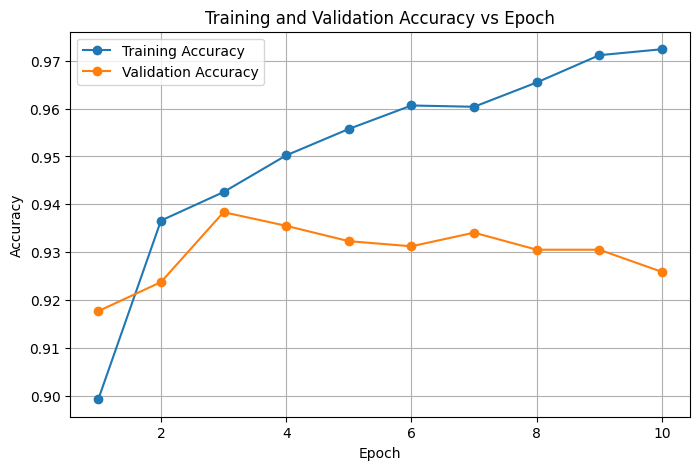

In [19]:
epochs_range = range(1,len(train_accuracy) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range,train_accuracy,marker="o",label="Training Accuracy")
plt.plot(epochs_range,val_accuracy,marker="o",label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy vs Epoch")
plt.legend()
plt.grid()

plt.show()

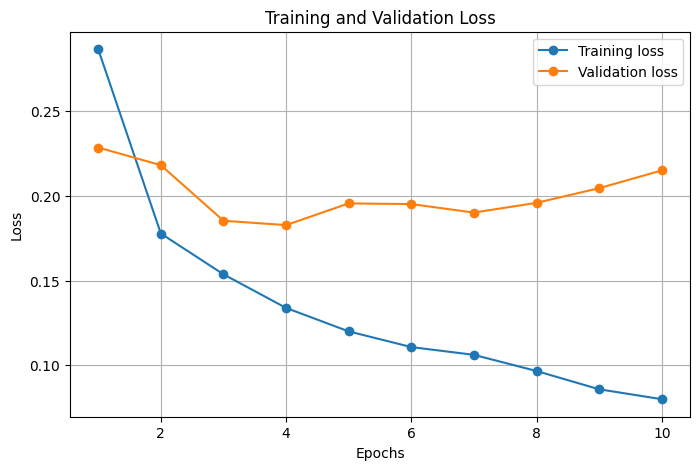

In [20]:

plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_loss , marker='o',label="Training loss")
plt.plot(epochs_range, val_loss , marker='o',label="Validation loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

TASK D: USING HUGGING FACE PRE-TRIANED MODEL

In [21]:
!pip install -q -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 121.9 MB/s eta 0:00:00


In [22]:
from transformers import(AutoImageProcessor, AutoModelForImageClassification)

from PIL import Image
import torch
import matplotlib.pyplot as plt
import numpy as np

In [23]:
model_name="google/vit-base-patch16-224"

processor=AutoImageProcessor.from_pretrained(model_name)
hf_model=AutoModelForImageClassification.from_pretrained(model_name)

print("Hugging Face Model Loaded Successfully")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Hugging Face Model Loaded Successfully


In [24]:
for images,labels in test_ds.take(1):
  sample_image=images[0]
  actual_label=labels[0].numpy()
  break

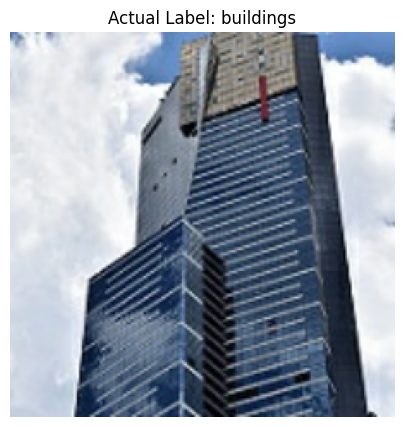

In [25]:
plt.figure(figsize=(5,5))
plt.imshow(sample_image.numpy().astype("uint8"))
plt.axis("off")
plt.title(f"Actual Label: {class_name[actual_label]}")
plt.show()

In [26]:
sample_numpy = (
    sample_image.numpy()
    .astype("uint8")
)
pil_image=Image.fromarray(sample_numpy)
inputs=processor(
    images=pil_image,return_tensors='pt'
)
with torch.no_grad():
  logits=hf_model(**inputs).logits

predicted_id = logits.argmax(dim=-1).item()
hf_prediction=(hf_model.config.id2label[predicted_id])

print(f"Predicted Label: {hf_prediction}")
probablities=torch.nn.functional.softmax(logits,dim=-1)
hf_confidence=probablities[0,predicted_id].item()


Predicted Label: airship, dirigible


In [27]:
resnet_input=tf.expand_dims(sample_image,axis=0)
resnet_output=model.predict(resnet_input)
resnet_index=np.argmax(resnet_output[0])
resnet_class=class_name[resnet_index]
resnet_confidence=np.max(resnet_output[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


In [28]:
print("\nPrediction COmparison")
print("Actual class: ",class_name[actual_label])
print("ResNet50 Prediction: ",resnet_class)
print(f"ResNet50 Confidence: "f"{resnet_confidence * 100:.2f}%")
print("Hugging Face Prediction: ",hf_prediction)

print(f"Hugging Face Confidence: "f"{hf_confidence * 100:.2f}%")


Prediction COmparison
Actual class:  buildings
ResNet50 Prediction:  buildings
ResNet50 Confidence: 99.98%
Hugging Face Prediction:  airship, dirigible
Hugging Face Confidence: 19.55%
